# 🌱 FROM FARM TO 400g 🍎

### Can our food systems supply enough fruits and vegetables for a healthy plate?

<a id="toc"></a>

## Table of Contents

1. [Project Overview](#project-overview)
   - [1.1 Problem, Objective & Research Questions](#overview-questions)
   - [1.2 Key Results at a Glance](#key-results)
   - [1.3 Analytical Methodology at a Glance](#methodology)

2. [Data Preparation & Quality](#data-preparation)
   - [2.1 Bronze - Silver - Gold Pipeline](#pipeline)
   - [2.2 Data Cleaning Rules](#cleaning-rules)
   - [2.3 Key Data Quality Findings](#data-quality)
   - [2.4 Final Analytical Dataset](#final-dataset)
   - [2.5 Analysis Setup & Validation](#analysis-setup)

3. [Research-Question Analysis](#research-analysis)
   - [3.1 RQ1 - Where?](#rq1)
   - [3.2 RQ2 - Progress?](#rq2)
   - [3.3 RQ3 - Patterns?](#rq3)

4. [Robustness & Interpretation](#robustness)
   - [4.1 Analytical Safeguards](#safeguards)
   - [4.2 Coverage Sensitivity Check](#coverage-sensitivity)
   - [4.3 Pearson vs Spearman Sensitivity Check](#sensitivity)
   - [4.4 Interpretation Guardrails](#guardrails)

5. [Implications & Conclusion](#implications)
   - [5.1 Evidence-Aligned Implications](#evidence-implications)
   - [5.2 Final Synthesis](#final-synthesis)
   - [5.3 Limitations](#limitations)
   - [5.4 Sources & References](#sources)


<a id="project-overview"></a>

## 1. Project Overview

<a id="overview-questions"></a>

### 1.1 Problem, Objective & Research Questions

[WHO healthy-diet guidance](https://www.who.int/news-room/fact-sheets/detail/healthy-diet) recommends at least **400 g/day of fruits and vegetables for individuals older than 10 years**. As part of a healthy, balanced diet, adequate fruit and vegetable intake is associated with a lower risk of cardiovascular disease and certain cancers.

Though the 400 g/day recommendation sets a clear dietary target, achieving it also depends on whether our food systems can support it. That led us to look beyond dietary guidance and examine the supply side of the equation:

> **Can our food systems supply enough fruits and vegetables for a healthy plate?**

**Objective:** Measure the gap between national fruit-and-vegetable availability and the **400 g/person/day healthy-diet reference**, then investigate the food-system patterns associated with countries that fall short.

**Main Stakeholders:** Nutrition and public-health bodies, agriculture and trade policymakers, FAO and WHO analysts.

Using FAOSTAT Food Balance data for **2014–2023**, Byte Crew explores three connected research questions:

1. **RQ1: WHERE? -** Where did fruit and vegetable (F&V) availability fall relative to the **400 g/person/day reference** across the study period?

2. **RQ2: PROGRESS? -** How did countries move relative to the **400 g/day reference** from their first to their last available observation?

3. **RQ3: PATTERNS? -** What food-system patterns characterize countries whose **period-average F&V availability was below 400 g/day** across the study period?

> **Availability ≠ consumption**  
> **Correlation ≠ causation**

<a id="key-results"></a>

### 1.2 Key Results at a Glance

**1. Nearly one-third of countries had period-average availability below the 400 g/day reference, with the deepest gaps concentrated in a small group.**  

Across 2014–2023, **57 of 178 countries (32.0%)** had period-average apparent F&V availability below **400 g/person/day**, while **121 countries (68.0%)** met or exceeded it. The five largest period-average shortfalls were observed in **Ethiopia, Zambia, Gambia, Timor-Leste, and Lesotho**, with gaps ranging from about **271 to 337 g/person/day below the reference**.

**2. RQ2 shows two complementary views: benchmark transition and first-to-last direction.**  

The validated hierarchical benchmark-transition categories are **111 Above 400g**, **12 Reached 400g**, **30 Closing the gap**, and **25 Moving away**. Independently of those threshold categories, **98 countries increased and 80 decreased** from their first to last available observation. Importantly, **55 of the 111 countries that started and ended above 400 g/day still declined over the period**, so the 25-country `Moving away` category should not be interpreted as the total number of countries with declining availability.

**3. Below-400 countries were characterized by much lower production and imports, while recorded losses showed a smaller difference.**  

Median F&V production was **97.2 kg/person/year** in below-400 countries versus **215.3 kg/person/year** among countries meeting the reference, while median imports were **11.8 versus 99.7 kg/person/year**. Recorded loss shares were much closer at **8.6% versus 7.1%**, with production showing the strongest positive association with availability among below-400 countries.


<a id="methodology"></a>

### 1.3 Analytical Methodology at a Glance

We used a **country-first, exploratory food-systems analysis approach** with FAOSTAT Food Balance data covering **2014–2023**. 

**Tools Used:** Data accessed from FAOSTAT; cleaned and analysed in Python (PySpark, pandas, NumPy); visualised with Matplotlib and Plotly. 


During data preparation, fruit and vegetable supply was combined and converted to **g/person/day**. The analysis then examined each country’s **typical position relative to the 400 g/day reference**, its **first-to-last progress**, and the **food-system patterns associated with countries classified below 400 g/day on a period-average basis**. Correlation analysis explores the **strength and direction of associations** between selected food-system indicators and F&V availability; it is not used for causal inference.

#### Core Calculations

**Period-average F&V availability**  
`Mean annual F&V availability (g/person/day) across available years`

**400G Availability Gap**  
`Period-average F&V availability − 400`

**Period Shortfall**  
`max(400 − Period-average F&V availability, 0)`

**Supply Adequacy %**  
`Period-average F&V availability ÷ 400 × 100`

Countries are classified as **Below 400g** or **Meets 400g** using period-average availability. Progress is assessed using each country’s **first and last available observations**, while production, imports, and recorded loss share are analysed using **available cases for each indicator**.


<a id="data-preparation"></a>

## 2. Data Preparation & Quality

<a id="pipeline"></a>

### 2.1 Bronze → Silver → Gold Pipeline

The project follows a **Bronze → Silver → Gold** data pipeline. 
- **Bronze** represents the original FAOSTAT Food Balance source extracts as received/downloaded. 
- **Silver** contains the curated country and regional FAOSTAT records retained for the **2014–2023** project scope: Fruits - Excluding Wine, Vegetables, and the selected food-system elements. 
- **Gold** reorganizes the country-level Silver data to a country-year analytical structure, combines fruit and vegetable measures where the required components are available, derives the 400 g/day benchmark and progress measures, and adds the food-system indicators used in RQ3. 


<a id="cleaning-rules"></a>

### 2.2 Data Cleaning Rules

- Restricted the analysis period to **2014–2023**.
- Retained **Fruits - Excluding Wine** and **Vegetables** as the two F&V item groups.
- Used **Food supply quantity (kg/capita/yr)** as the primary availability measure.
- Retained the supporting elements needed to investigate food-system patterns, including **production, imports, exports, domestic supply, food, losses, processing, and residuals** at the Silver stage.
- Kept **country records separate from official World and regional aggregates** to avoid geographic overlap and double counting.
- Excluded the aggregate **China** record from country-level analysis because it overlaps with separately reported China areas.
- Required both fruit and vegetable components before calculating a combined F&V total for an element.
- Preserved genuine **missing values as missing** rather than converting absent records to zero.
- Converted combined F&V availability from **kg/capita/year to g/person/day** using `(kg/cap/year × 1000) ÷ 365`.
- Derived the signed **Gap to 400**, annual benchmark status, period-average benchmark status, and first-to-last progress fields.
- Retained coverage and QA fields so incomplete time coverage or food-system indicators remain visible during analysis.
- Retained unusual observations unless the source evidence indicated an error; magnitude alone was not used as a reason for deletion.

<a id="data-quality"></a>

### 2.3 Key Data Quality Findings

| **Data quality finding** | **Evidence found** | **Treatment / decision** |
|---|---|---|
| **China geographic overlap** | The Silver country extract contained an aggregate `China` record alongside separately reported China areas. | Excluded the aggregate China record from country-level analysis, reducing the analytical geography from **179 to 178 countries/areas**. |
| **Uneven country-year coverage** | Of the 178 analytical countries/areas, **168 have all 10 years**, while **10 have partial coverage** within 2014–2023. | No imputation was applied. RQ1 averages each country's available years and RQ2 uses its first and last available observations; coverage status remains explicit. |
| **Missingness is mainly structural** | The Silver extract contains few ordinary blank cells; missingness often appears as an **absent country-year-item record**. | Combined indicators are calculated only when the required fruit and vegetable components exist; otherwise the result remains missing. |
| **Production has limited component gaps** | Production is not complete for every country-year and F&V component, including a small number of fully missing or one-component country-years. | Missing production is preserved as missing rather than interpreted as zero. |
| **Imports are comparatively complete** | Import quantity contains both fruit and vegetable components for all **1,731 analytical country-year pairs**. | Retained as a core RQ3 indicator and standardized to kg/person/year. |
| **Loss data contain some component gaps** | Loss records cover all analytical country-years, but a small number lack one of the two F&V components. | Combined loss measures remain missing when both components are not available; RQ3 uses indicator-specific available cases. |
| **Processing is substantially incomplete** | Processing is available for fewer countries and often contains only one F&V component; only **316 country-years** had both fruit and vegetable processing components in the supplied Silver data. | Processing was retained during exploration but not used as a primary RQ3 comparison indicator. |
| **FAOSTAT source flags** | The supplied Silver observations carry the FAOSTAT **`E = Estimated value`** flag. | Source flags were retained during preparation and the results are interpreted as descriptive estimates rather than exact observed quantities. |
| **Official regional aggregates differ from country classifications** | The regional Silver file contains official FAOSTAT aggregates for World, Africa, Americas, Asia, Europe, and Oceania, while the final Gold dataset is country-based. | Regional aggregates were kept separate from the country analytical dataset and are not mixed into RQ1–RQ3 country counts. |

<a id="final-dataset"></a>

### 2.4 Final Analytical Dataset

After these checks, the consolidated analytical dataset contains **1,731 country-year observations across 178 countries/areas**. It includes annual F&V availability and gap measures, period-average benchmark fields for RQ1, first-to-last progress fields for RQ2, and period-average production, imports, and recorded loss-share measures for RQ3. Country-period fields are repeated across each country's annual rows so both annual exploration and one-row-per-country analysis can be produced from the same file. Missing food-system indicators remain missing, and RQ3 therefore uses **indicator-specific available cases** rather than a single universal complete-case sample.

<a id="analysis-setup"></a>

### 2.5 Analysis Setup & Validation

We imported the required libraries, defined the shared chart styling, loaded the consolidated analytical dataset, and performed a compact structural validation. 

[↑ Back to Table of Contents](#toc)

In [0]:

from pyspark.sql import functions as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Team Databricks Gold path.
GOLD_PATH = "/Volumes/workspace/byte_crew/raw/Faostat_Fbs_Gold_Dataset.csv"
BENCHMARK = 400.0
# Tolerance used by recalculation QA for rounded Gold fields.
TOL = 0.2  # accommodates fields stored/displayed to one decimal place

# Visual style for all charts.
FOCUS_COLOR = "#7AAF55"
FOCUS_DARK = "#3B6A2E"
FOCUS_LIGHT = "#B4D693"
FOCUS_PALE = "#E6F1DA"
CONTEXT_COLOR = "#CFCBC4"
CONTEXT_DARK = "#8F8B85"
TEXT_COLOR = "#513E6B"
BENCH_COLOR = "#513E6B"
BACKGROUND = "white"

# Choropleth scale: focus tints below 400 g/day, greys above, capped at 800.
MAP_SCALE = [
    [0.00, FOCUS_DARK],
    [0.20, FOCUS_COLOR],
    [0.40, FOCUS_LIGHT],
    [0.49, FOCUS_PALE],
    [0.50, "#E9E7E3"],
    [0.65, "#D7D5D0"],
    [0.82, "#BDBAB4"],
    [1.00, "#9A978F"]
]

# Plotly country-name normalization for common FAOSTAT naming variants.
# This is a visualization-only mapping; analytical country labels are preserved unchanged.
MAP_NAME_ALIASES = {
    "Bolivia (Plurinational State of)": "Bolivia",
    "China, mainland": "China",
    "China, Hong Kong SAR": "Hong Kong",
    "China, Macao SAR": "Macao",
    "China, Taiwan Province of": "Taiwan",
    "Democratic People's Republic of Korea": "North Korea",
    "Iran (Islamic Republic of)": "Iran",
    "Lao People's Democratic Republic": "Laos",
    "Micronesia (Federated States of)": "Micronesia",
    "Naoero": "Nauru",
    "Republic of Korea": "South Korea",
    "Republic of Moldova": "Moldova",
    "Russian Federation": "Russia",
    "State of Palestine": "Palestine",
    "Syrian Arab Republic": "Syria",
    "Türkiye": "Turkey",
    "United Republic of Tanzania": "Tanzania",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Viet Nam": "Vietnam"
}

plt.rcParams.update({
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "axes.edgecolor": "none",
    "axes.labelcolor": TEXT_COLOR,
    "axes.titlecolor": TEXT_COLOR,
    "text.color": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    "font.size": 11
})

gold = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(GOLD_PATH)
)

# Structural integrity QA.
# A. Structural checks

qa_basic = (
    gold.agg(
        F.count("*").alias("rows"),
        F.countDistinct("Country").alias("countries"),
        F.min("Year").alias("min_year"),
        F.max("Year").alias("max_year")
    )
    .first()
)

print(f"Gold rows: {qa_basic['rows']:,}")
print(f"Unique countries: {qa_basic['countries']:,}")
print(f"Year range: {qa_basic['min_year']}–{qa_basic['max_year']}")

assert qa_basic["rows"] == 1731, "Unexpected Gold row count."
assert qa_basic["countries"] == 178, "Unexpected country count."
assert qa_basic["min_year"] == 2014 and qa_basic["max_year"] == 2023, "Unexpected year range."

duplicate_country_years = (
    gold.groupBy("Country", "Year")
    .count()
    .filter(F.col("count") > 1)
    .count()
)
assert duplicate_country_years == 0, "Duplicate Country-Year rows found in Gold."

country_to_m49_conflicts = (
    gold.groupBy("Country")
    .agg(F.countDistinct("M49").alias("m49_n"))
    .filter(F.col("m49_n") > 1)
    .count()
)
m49_to_country_conflicts = (
    gold.filter(F.col("M49").isNotNull())
    .groupBy("M49")
    .agg(F.countDistinct("Country").alias("country_n"))
    .filter(F.col("country_n") > 1)
    .count()
)
assert country_to_m49_conflicts == 0, "A country maps to more than one M49 code."
assert m49_to_country_conflicts == 0, "An M49 code maps to more than one country."

# Validate repeated country-period fields before reducing to one row per country.
# B. Validate repeated country-period fields BEFORE reducing to one row

period_fields = [
    "M49",
    "Years_Observed",
    "Coverage_Status",
    "Start_Year",
    "End_Year",
    "Period_Avg_FV_g_person_day",
    "Period_Gap_to_400_g_day",
    "Period_Shortfall_g_day",
    "Period_Benchmark_Status",
    "Start_FV_g_person_day",
    "End_FV_g_person_day",
    "Change_g_person_day",
    "Progress_Category",
    "Period_Avg_Production_kg_person_year",
    "Period_Avg_Imports_kg_person_year",
    "Period_Avg_Loss_Share_pct",
    "Pattern_Years_Complete",
    "Pattern_Period_Status",
    "RQ3_Eligible"
]

period_consistency = gold.groupBy("Country").agg(
    F.count("*").alias("__rows"),
    *[
        expr
        for c in period_fields
        for expr in (
            F.countDistinct(F.col(c)).alias(f"{c}__distinct"),
            F.count(F.col(c)).alias(f"{c}__nonnull")
        )
    ]
)

conflict_condition = None
for c in period_fields:
    # A repeated field is valid only when it is:
    #   (a) all null, or
    #   (b) non-null on every annual row with one distinct value.
    mixed_nulls = (
        (F.col(f"{c}__nonnull") > 0) &
        (F.col(f"{c}__nonnull") < F.col("__rows"))
    )
    check = (F.col(f"{c}__distinct") > 1) | mixed_nulls
    conflict_condition = check if conflict_condition is None else (conflict_condition | check)

period_conflicts = period_consistency.filter(conflict_condition)
assert period_conflicts.count() == 0, (
    "Repeated country-period fields are inconsistent across annual rows. "
    "Inspect period_conflicts before creating country_summary."
)

# Safe only after the consistency assertion above.
country_summary = (
    gold.select("Country", *period_fields)
    .dropDuplicates(["Country"])
    # Core project KPI.
    .withColumn(
        "Supply_Adequacy_pct",
        F.round(F.col("Period_Avg_FV_g_person_day") / F.lit(BENCHMARK) * 100, 1)
    )
)

assert country_summary.count() == 178, "Country summary should contain 178 unique countries."

# Recalculation and formula QA.
# C. Recalculate core fields from annual rows and compare with Gold

recalc = (
    gold.groupBy("Country")
    .agg(
        F.countDistinct("Year").alias("Years_Observed_recalc"),
        F.min("Year").alias("Start_Year_recalc"),
        F.max("Year").alias("End_Year_recalc"),
        F.avg("FV_g_person_day").alias("Period_Avg_FV_recalc")
    )
)

recalc_check = (
    country_summary
    .join(recalc, on="Country", how="inner")
    .withColumn(
        "Period_Gap_recalc",
        F.col("Period_Avg_FV_recalc") - F.lit(BENCHMARK)
    )
    .withColumn(
        "Period_Shortfall_recalc",
        F.greatest(
            F.lit(BENCHMARK) - F.col("Period_Avg_FV_recalc"),
            F.lit(0.0)
        )
    )
)

assert recalc_check.filter(
    F.col("Years_Observed") != F.col("Years_Observed_recalc")
).count() == 0, "Years_Observed does not match annual-row coverage."

assert recalc_check.filter(
    (F.col("Start_Year") != F.col("Start_Year_recalc")) |
    (F.col("End_Year") != F.col("End_Year_recalc"))
).count() == 0, "Stored start/end years do not match annual observations."

assert recalc_check.filter(
    F.abs(F.col("Period_Avg_FV_g_person_day") - F.col("Period_Avg_FV_recalc")) > TOL
).count() == 0, "Stored period-average availability does not match annual recomputation."

assert recalc_check.filter(
    F.abs(F.col("Period_Gap_to_400_g_day") - F.col("Period_Gap_recalc")) > TOL
).count() == 0, "Stored period gap does not match Availability − 400."

assert recalc_check.filter(
    F.abs(F.col("Period_Shortfall_g_day") - F.col("Period_Shortfall_recalc")) > TOL
).count() == 0, "Stored period shortfall does not match max(400 − Availability, 0)."

annual_gap_mismatches = gold.filter(
    F.abs(
        F.col("Gap_to_400_g_day") -
        (F.col("FV_g_person_day") - F.lit(BENCHMARK))
    ) > TOL
).count()
assert annual_gap_mismatches == 0, "Annual gap formula mismatch found."

benchmark_mismatches = country_summary.filter(
    F.col("Period_Benchmark_Status") !=
    F.when(
        F.col("Period_Avg_FV_g_person_day") < F.lit(BENCHMARK),
        F.lit("Below 400g")
    ).otherwise(F.lit("Meets 400g"))
).count()
assert benchmark_mismatches == 0, "Period benchmark status is inconsistent with period-average availability."

expected_progress = (
    F.when(
        (F.col("Start_FV_g_person_day") >= F.lit(BENCHMARK)) &
        (F.col("End_FV_g_person_day") >= F.lit(BENCHMARK)),
        F.lit("Above 400g")
    )
    .when(
        (F.col("Start_FV_g_person_day") < F.lit(BENCHMARK)) &
        (F.col("End_FV_g_person_day") >= F.lit(BENCHMARK)),
        F.lit("Reached 400g")
    )
    .when(F.col("End_FV_g_person_day") > F.col("Start_FV_g_person_day"), F.lit("Closing the gap"))
    .when(F.col("End_FV_g_person_day") < F.col("Start_FV_g_person_day"), F.lit("Moving away"))
    .otherwise(F.lit("Stable"))
)

progress_mismatches = country_summary.filter(
    F.col("Progress_Category") != expected_progress
).count()
assert progress_mismatches == 0, "Progress_Category does not match the documented hierarchical endpoint rules."

complete_coverage_count = country_summary.filter(F.col("Years_Observed") == 10).count()
assert complete_coverage_count == 168, "Expected 168 countries with complete 10-year coverage."

print("Core QA checks passed.")
display(gold.limit(10))


Gold rows: 1,731
Unique countries: 178
Year range: 2014–2023
Core QA checks passed.


M49,Country,Year,Years_Observed,Coverage_Status,Start_Year,End_Year,Fruit_Supply_kg_cap_yr,Vegetable_Supply_kg_cap_yr,FV_Supply_kg_cap_yr,FV_g_person_day,Gap_to_400_g_day,Annual_Benchmark_Status,Period_Avg_FV_g_person_day,Period_Gap_to_400_g_day,Period_Shortfall_g_day,Period_Benchmark_Status,Start_FV_g_person_day,End_FV_g_person_day,Change_g_person_day,Progress_Category,FV_Food_1000t,FV_Production_1000t,FV_Imports_1000t,FV_Domestic_Supply_1000t,FV_Losses_1000t,Implied_Population_1000_persons,FV_Production_kg_person_year,FV_Imports_kg_person_year,Loss_Share_pct,Period_Avg_Production_kg_person_year,Period_Avg_Imports_kg_person_year,Period_Avg_Loss_Share_pct,Production_Data_Status,Loss_Data_Status,Pattern_QA_Status,Pattern_Years_Complete,Pattern_Period_Status,RQ3_Eligible
4,Afghanistan,2014,10,Complete 2014-2023,2014,2023,36.19,51.71,87.9,240.82191780821918,-159.17808219178082,Below 400g,272.08493150684933,-127.91506849315067,127.91506849315067,Below 400g,240.82191780821918,283.09589041095893,42.27397260273975,Closing the gap,2883.0,2688.0,756.0,3112.0,256.0,32798.634812286684,81.95463059313217,23.04973985431842,8.226221079691516,109.15296374545258,18.816745769083738,9.792417512111601,Complete,Complete,Complete,10,Complete period,Yes
4,Afghanistan,2015,10,Complete 2014-2023,2014,2023,36.59,43.32,79.91,218.93150684931507,-181.06849315068493,Below 400g,272.08493150684933,-127.91506849315067,127.91506849315067,Below 400g,240.82191780821918,283.09589041095893,42.27397260273975,Closing the gap,2703.0,2840.0,469.0,2948.0,269.0,33825.55374796646,83.96019237883833,13.86525712171661,9.12483039348711,109.15296374545258,18.816745769083738,9.792417512111601,Complete,Complete,Complete,10,Complete period,Yes
4,Afghanistan,2016,10,Complete 2014-2023,2014,2023,33.34,79.26,112.60000000000001,308.49315068493155,-91.50684931506845,Below 400g,272.08493150684933,-127.91506849315067,127.91506849315067,Below 400g,240.82191780821918,283.09589041095893,42.27397260273975,Closing the gap,3908.0,4046.0,758.0,4268.0,408.0,34706.927175843695,116.57615148413511,21.840020470829067,9.559512652296158,109.15296374545258,18.816745769083738,9.792417512111601,Complete,Complete,Complete,10,Complete period,Yes
4,Afghanistan,2017,10,Complete 2014-2023,2014,2023,39.08,66.52,105.6,289.3150684931507,-110.6849315068493,Below 400g,272.08493150684933,-127.91506849315067,127.91506849315067,Below 400g,240.82191780821918,283.09589041095893,42.27397260273975,Closing the gap,3769.0,3713.0,900.0,4090.0,363.0,35691.28787878788,104.03098965242769,25.21623772884054,8.875305623471883,109.15296374545258,18.816745769083738,9.792417512111601,Complete,Complete,Complete,10,Complete period,Yes
4,Afghanistan,2018,10,Complete 2014-2023,2014,2023,37.36,40.28,77.64,212.7123287671233,-187.2876712328767,Below 400g,272.08493150684933,-127.91506849315067,127.91506849315067,Below 400g,240.82191780821918,283.09589041095893,42.27397260273975,Closing the gap,2853.0,3185.0,792.0,3029.0,276.0,36746.52241112828,86.67486855941115,21.553059936908518,9.111918124793661,109.15296374545258,18.816745769083738,9.792417512111601,Complete,Complete,Complete,10,Complete period,Yes
4,Afghanistan,2019,10,Complete 2014-2023,2014,2023,38.57,62.05,100.62,275.67123287671234,-124.32876712328766,Below 400g,272.08493150684933,-127.91506849315067,127.91506849315067,Below 400g,240.82191780821918,283.09589041095893,42.27397260273975,Closing the gap,3809.0,4514.0,712.0,4139.0,427.0,37855.297157622736,119.24354948805461,18.808464163822528,10.31650157042764,109.15296374545258,18.816745769083738,9.792417512111601,Complete,Complete,Complete,10,Complete period,Yes
4,Afghanistan,2020,10,Complete 2014-2023,2014,2023,37.99,81.66,119.65,327.8082191780822,-72.1917808219178,Below 400g,272.08493150684933,-127.91506849315067,127.91506849315067,Below 400g,240.82191780821918,283.09589041095893,42.27397260273975,Closing the gap,4674.0,5271.0,636.0,5086.0,516.0,39063.9364814041,134.9326379974326,16.281001283697048,10.145497443963821,109.1529637454

<a id="research-analysis"></a>

## 3. Research-Question Analysis

The analytical sequence is:

**Where is the period-average gap?** → **How did countries move?** → **What food-system patterns distinguish countries still below 400?**

<a id="rq1"></a>

### 3.1 RQ1 - WHERE?
#### Where was F&V availability typically below 400 g/day during 2014–2023?

RQ1 uses each country's **period-average F&V availability**.

#### 3.1.1 Period-Average Benchmark Classification

We summarized the period-average benchmark status already calculated in the analytical dataset.

**Analytical unit:** one country  
**Time basis:** each country's available observations within 2014–2023  
**Benchmark:** 400 g/person/day

The code:
1. groups the one-row-per-country table by `Period_Benchmark_Status`;
2. counts countries in each benchmark group;
3. calculates each group's share of the 178-country analytical base;
4. independently recounts the Below-400 group;

In [0]:
# We summarized period-average benchmark status at one row per country.

rq1_counts = (
    country_summary
    .groupBy("Period_Benchmark_Status")
    .count()
    .withColumn(
        "Percent_of_Countries",
        F.round(F.col("count") / F.lit(178) * 100, 1)
    )
    .orderBy("Period_Benchmark_Status")
)

display(rq1_counts)

below_count = (
    country_summary
    .filter(F.col("Period_Benchmark_Status") == "Below 400g")
    .count()
)

assert below_count == 57, "RQ1 below-400 count no longer matches the validated Gold dataset."

Period_Benchmark_Status,count,Percent_of_Countries
Below 400g,57,32.0
Meets 400g,121,68.0


<a id="largest-gaps"></a>

#### 3.1.2 Largest Period-Average Shortfalls

To answer the headline question directly, we rank countries whose period-average apparent F&V availability is below 400 g/person/day by the size of their **period shortfall**.

The table adds **Supply Adequacy %**:

`Period-average apparent F&V availability ÷ 400 × 100`

This expresses national apparent availability relative to the 400 g/day reference. It is **not** a measure of the share of people meeting dietary recommendations.

The chart shows the 15 largest period-average shortfalls. Ranking is based on shortfall only; it is not a policy-priority ranking.


Country,Period_Avg_FV_g_person_day,Period_Gap_to_400_g_day,Period_Shortfall_g_day,Supply_Adequacy_pct,Years_Observed,Coverage_Status,Progress_Category
Ethiopia,62.51506849315068,-337.4849315068493,337.4849315068493,15.6,10,Complete 2014-2023,Closing the gap
Zambia,80.4876712328767,-319.5123287671233,319.5123287671233,20.1,10,Complete 2014-2023,Moving away
Gambia,116.53424657534246,-283.4657534246575,283.4657534246575,29.1,10,Complete 2014-2023,Moving away
Timor-Leste,124.98082191780821,-275.0191780821918,275.0191780821918,31.2,10,Complete 2014-2023,Closing the gap
Lesotho,128.6931506849315,-271.30684931506846,271.30684931506846,32.2,10,Complete 2014-2023,Moving away
Yemen,130.23835616438356,-269.76164383561644,269.76164383561644,32.6,10,Complete 2014-2023,Moving away
Solomon Islands,140.26027397260273,-259.7397260273973,259.7397260273973,35.1,10,Complete 2014-2023,Moving away
Cambodia,151.2027397260274,-248.7972602739726,248.7972602739726,37.8,10,Complete 2014-2023,Moving away
Madagascar,153.1041095890411,-246.8958904109589,246.8958904109589,38.3,10,Complete 2014-2023,Moving away
Pakistan,162.67123287671234,-237.32876712328766,237.32876712328766,40.7,10,Complete 2014-2023,Moving away


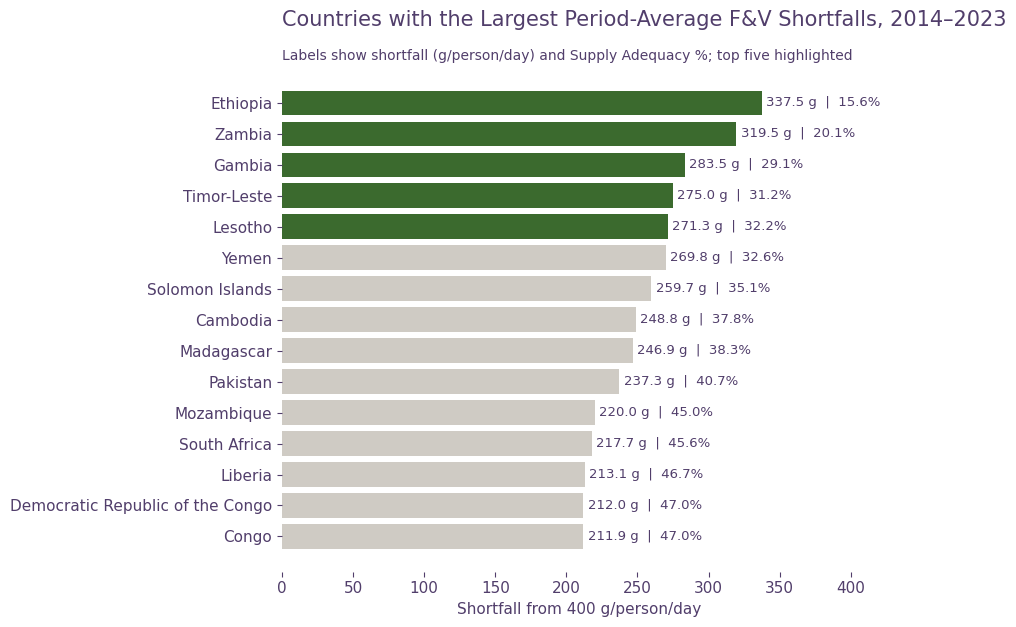

In [0]:
# Rank below-reference countries by the size of their period-average shortfall.

largest_gaps = (
    country_summary
    .filter(F.col("Period_Benchmark_Status") == "Below 400g")
    .select(
        "Country",
        "Period_Avg_FV_g_person_day",
        "Period_Gap_to_400_g_day",
        "Period_Shortfall_g_day",
        "Supply_Adequacy_pct",
        "Years_Observed",
        "Coverage_Status",
        "Progress_Category"
    )
    .orderBy(
        F.col("Period_Shortfall_g_day").desc(),
        F.col("Country").asc()
    )
)

top15_gaps_pd = largest_gaps.limit(15).toPandas()

assert len(top15_gaps_pd) == 15, "Expected 15 countries in the headline shortfall ranking."
assert (top15_gaps_pd["Period_Shortfall_g_day"] > 0).all(), "Shortfall ranking contains a non-positive value."
assert top15_gaps_pd["Period_Shortfall_g_day"].is_monotonic_decreasing, "Shortfall ranking is not descending."

display(largest_gaps.limit(15))

# Plot the same top-15 ranking.
plot_gap = top15_gaps_pd.sort_values("Period_Shortfall_g_day", ascending=True).copy()
plot_gap["Highlight"] = [
    "Top 5" if rank <= 5 else "Context"
    for rank in plot_gap["Period_Shortfall_g_day"].rank(method="first", ascending=False)
]

fig, ax = plt.subplots(figsize=(9.0, 6.4))

bars = ax.barh(
    plot_gap["Country"],
    plot_gap["Period_Shortfall_g_day"],
    color=[
        FOCUS_DARK if group == "Top 5" else CONTEXT_COLOR
        for group in plot_gap["Highlight"]
    ],
    edgecolor="none"
)

for bar, shortfall, adequacy in zip(
    bars,
    plot_gap["Period_Shortfall_g_day"],
    plot_gap["Supply_Adequacy_pct"]
):
    ax.text(
        shortfall + 3,
        bar.get_y() + bar.get_height()/2,
        f"{shortfall:.1f} g  |  {adequacy:.1f}%",
        va="center",
        fontsize=9.5,
        color=TEXT_COLOR
    )

ax.set_title(
    "Countries with the Largest Period-Average F&V Shortfalls, 2014–2023",
    loc="left",
    fontsize=15,
    color=TEXT_COLOR,
    pad=30
)
ax.set_xlabel("Shortfall from 400 g/person/day")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.margins(x=0.24)

ax.text(
    0.0,
    1.01,
    "Labels show shortfall (g/person/day) and Supply Adequacy %; top five highlighted",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color=TEXT_COLOR
)

plt.tight_layout()
plt.show()

#### 3.1.3 Geographic Distribution

We mapped where period-average F&V availability was higher or lower across countries using the same one-country analytical view as the RQ1 summary.

**Map scale note:** The color scale is capped at 800 g/person/day to keep the 400 g/day reference visually interpretable. Countries above 800 g/day therefore share the upper-end color and should not be read as having equal availability.


In [0]:
# We mapped the same period-average country sample and added soft boxed region labels.

import plotly.express as px
import plotly.graph_objects as go

rq1_map_pd = (
    country_summary
    .select(
        "Country",
        "Period_Avg_FV_g_person_day",
        "Period_Gap_to_400_g_day",
        "Period_Benchmark_Status"
    )
    .toPandas()
)

# Normalize known FAOSTAT naming variants for Plotly without changing analytical labels.
rq1_map_pd["Map_Location"] = rq1_map_pd["Country"].replace(MAP_NAME_ALIASES)
map_aliases_used = (
    rq1_map_pd.loc[rq1_map_pd["Map_Location"] != rq1_map_pd["Country"], ["Country", "Map_Location"]]
    .drop_duplicates()
    .sort_values("Country")
)
print(f"Map-name QA: {len(map_aliases_used)} FAOSTAT naming variant(s) normalized for Plotly.")
if len(map_aliases_used):
    display(map_aliases_used)

fig = px.choropleth(
    rq1_map_pd,
    locations="Map_Location",
    locationmode="country names",
    color="Period_Avg_FV_g_person_day",
    hover_name="Country",
    hover_data={
        "Period_Avg_FV_g_person_day": ":.1f",
        "Period_Gap_to_400_g_day": ":.1f",
        "Period_Benchmark_Status": True
    },
    color_continuous_scale=MAP_SCALE,
    range_color=(0, 800)
)

fig.update_geos(
    showcoastlines=True,
    coastlinecolor="#D8D8D3",
    showframe=False,
    showcountries=True,
    countrycolor="#F5F5F1",
    showland=True,
    landcolor="#F1F1EE",
    showocean=True,
    oceancolor="white"
)

fig.update_layout(
    title=dict(
        text="Period-Average F&V Availability by Country, 2014–2023",
        x=0.01,
        xanchor="left",
        font=dict(size=18, color=TEXT_COLOR)
    ),
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(l=0, r=0, t=55, b=0),
    coloraxis_colorbar=dict(
        title="g/person/day",
        tickvals=[0, 200, 400, 600, 800],
        thickness=12,
        len=0.72,
        outlinewidth=0,
        tickfont=dict(color="#6D6D68")
    )
)

region_annotations = [
    dict(text="<b>Americas</b>", x=0.16, y=0.48),
    dict(text="<b>Europe</b>",   x=0.50, y=0.71),
    dict(text="<b>Africa</b>",   x=0.50, y=0.45),
    dict(text="<b>Asia</b>",     x=0.70, y=0.66),
    dict(text="<b>Oceania</b>",  x=0.82, y=0.34),
]

for label in region_annotations:
    fig.add_annotation(
        x=label["x"],
        y=label["y"],
        xref="paper",
        yref="paper",
        text=label["text"],
        showarrow=False,
        font=dict(size=11, color="#666661"),
        bgcolor="rgba(242,242,239,0.95)",
        bordercolor="#DDDDD7",
        borderwidth=0.7,
        borderpad=4
    )

fig.show()

Map-name QA: 18 FAOSTAT naming variant(s) normalized for Plotly.


Country,Map_Location
Bolivia (Plurinational State of),Bolivia
"China, Hong Kong SAR",Hong Kong
"China, Macao SAR",Macao
"China, Taiwan Province of",Taiwan
"China, mainland",China
Democratic People's Republic of Korea,North Korea
Iran (Islamic Republic of),Iran
Lao People's Democratic Republic,Laos
Micronesia (Federated States of),Micronesia
Naoero,Nauru


#### 3.1.4 Annual Exploration

The period-average map provides the main RQ1 classification. The interactive view below adds the annual dimension: use the **year slider** to move through 2014–2023 and observe how country-level F&V availability changes over time.

The same boxed regional guide labels are retained here to make the animated geography easier to read.

**Annual map scale note:** The annual map uses the same 0–800 g/person/day color range; values above 800 are visually saturated for consistency with the period-average map.


**Map QA note:** The analytical country names are preserved in the data, while known FAOSTAT/Plotly naming variants are normalized only for visualization. Because Plotly resolves country-name geographies at render time, the final exported maps should still receive a visual completeness check for any blank or unexpectedly missing geographies.


In [0]:
# We added an annual map slider with the same soft boxed region labels.

annual_map_pd = (
    gold.select(
        "Country",
        "Year",
        "FV_g_person_day",
        "Gap_to_400_g_day",
        "Annual_Benchmark_Status",
        "Period_Benchmark_Status"
    )
    .orderBy("Year", "Country")
    .toPandas()
)

# Apply the same visualization-only country-name normalization used in the period map.
annual_map_pd["Map_Location"] = annual_map_pd["Country"].replace(MAP_NAME_ALIASES)

annual_fig = px.choropleth(
    annual_map_pd,
    locations="Map_Location",
    locationmode="country names",
    color="FV_g_person_day",
    animation_frame="Year",
    hover_name="Country",
    hover_data={
        "FV_g_person_day": ":.1f",
        "Gap_to_400_g_day": ":.1f",
        "Annual_Benchmark_Status": True,
        "Period_Benchmark_Status": True
    },
    range_color=(0, 800),
    color_continuous_scale=MAP_SCALE,
    labels={
        "FV_g_person_day": "F&V availability (g/person/day)",
        "Year": "Year"
    }
)

annual_fig.update_geos(
    showcoastlines=True,
    coastlinecolor="#D8D8D3",
    showframe=False,
    showcountries=True,
    countrycolor="#F5F5F1",
    showland=True,
    landcolor="#F1F1EE",
    showocean=True,
    oceancolor="white"
)

annual_fig.update_layout(
    title=dict(
        text="Annual F&V Availability by Country, 2014–2023",
        x=0.01,
        xanchor="left",
        font=dict(size=18, color=TEXT_COLOR)
    ),
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(l=0, r=0, t=55, b=0),
    transition_duration=0,
    coloraxis_colorbar=dict(
        title="g/person/day",
        tickvals=[0, 200, 400, 600, 800],
        thickness=12,
        len=0.72,
        outlinewidth=0,
        tickfont=dict(color="#6D6D68")
    )
)

region_annotations = [
    dict(text="<b>Americas</b>", x=0.16, y=0.48),
    dict(text="<b>Europe</b>",   x=0.50, y=0.71),
    dict(text="<b>Africa</b>",   x=0.50, y=0.45),
    dict(text="<b>Asia</b>",     x=0.70, y=0.66),
    dict(text="<b>Oceania</b>",  x=0.82, y=0.34),
]

for label in region_annotations:
    annual_fig.add_annotation(
        x=label["x"],
        y=label["y"],
        xref="paper",
        yref="paper",
        text=label["text"],
        showarrow=False,
        font=dict(size=11, color="#666661"),
        bgcolor="rgba(242,242,239,0.95)",
        bordercolor="#DDDDD7",
        borderwidth=0.7,
        borderpad=4
    )

annual_fig.show()

#### 3.1.5 Key Finding

**57 of 178 countries (32.0%)** had period-average apparent F&V availability below the 400 g/day reference.

The remaining **121 countries (68.0%)** met or exceeded the reference on a period-average basis.

This is a **country classification**, not a population-weighted estimate and not a measure of individual intake.

#### 3.1.6 Interpretation

The country-period view shows that the availability gap is **substantial but geographically uneven**. A large majority of countries met the reference on average, yet nearly one-third had period-average availability below it across their available study-period observations.

Because this is an average over time, it describes a country's **typical position during the period**. It does not imply that every annual observation remained on the same side of the benchmark.

[↑ Back to Table of Contents](#toc)

<a id="rq2"></a>

### 3.2 RQ2 - PROGRESS?
#### How did countries move relative to the 400 g/day reference?

RQ2 uses each country's **first and last available observations** within 2014–2023 and reports two complementary views:

1. **Benchmark-transition / progress category** — the existing hierarchical `Progress_Category`, which combines threshold status and movement.
2. **First-to-last direction** — whether availability **increased, decreased, or was stable**, calculated independently of benchmark status.

This distinction matters because a country can **decline while still starting and ending above 400 g/day**. Such a country remains in the `Above 400g` benchmark category and is therefore not counted in `Moving away`.


#### 3.2.1 Benchmark-Transition / Progress Definitions

The validated `Progress_Category` is **hierarchical**: threshold-based categories are assigned first, then the remaining countries are classified by the direction of their first-to-last change.

- **Above 400g:** started and ended at or above 400 g/day
- **Reached 400g:** started below 400 and ended at or above 400
- **Closing the gap:** after the two threshold categories above were assigned, ended higher than it started
- **Moving away:** after the threshold categories above were assigned, ended lower than it started
- **Stable:** no first-to-last change among the remaining countries

These are best interpreted as **benchmark-transition / progress categories**, not as a complete direction count. In particular, **Above 400g does not mean the country increased or stayed above 400 in every year**.


#### 3.2.2 Benchmark Categories and Independent Direction Check

We summarize the validated `Progress_Category` and then calculate a separate **first-to-last direction** directly from `Change_g_person_day`.

The companion direction check answers a different question from the hierarchical categories: **Did availability rise or fall from the first to the last available observation, regardless of threshold status?**

A benchmark-transition cross-tab is also produced so the relationship between threshold status and direction is transparent.


In [0]:
# We summarized the validated benchmark-transition categories and added an independent direction check.

rq2_detail = (
    country_summary
    .withColumn(
        "First_to_Last_Direction",
        F.when(F.col("Change_g_person_day") > 0, "Increased")
         .when(F.col("Change_g_person_day") < 0, "Decreased")
         .otherwise("Stable")
    )
    .withColumn(
        "Benchmark_Transition",
        F.when(
            (F.col("Start_FV_g_person_day") >= BENCHMARK) &
            (F.col("End_FV_g_person_day") >= BENCHMARK),
            "Above → Above"
        )
        .when(
            (F.col("Start_FV_g_person_day") < BENCHMARK) &
            (F.col("End_FV_g_person_day") >= BENCHMARK),
            "Below → Above"
        )
        .when(
            (F.col("Start_FV_g_person_day") < BENCHMARK) &
            (F.col("End_FV_g_person_day") < BENCHMARK),
            "Below → Below"
        )
        .otherwise("Above → Below")
    )
)

# A. Existing validated hierarchical benchmark/progress categories.
rq2_counts = (
    rq2_detail
    .groupBy("Progress_Category")
    .count()
    .withColumn(
        "Percent_of_Countries",
        F.round(F.col("count") / F.lit(178) * 100, 1)
    )
)

progress_order = [
    "Above 400g",
    "Reached 400g",
    "Closing the gap",
    "Moving away",
    "Stable"
]

rq2_pd = rq2_counts.toPandas()
rq2_pd["Progress_Category"] = pd.Categorical(
    rq2_pd["Progress_Category"],
    categories=progress_order,
    ordered=True
)
rq2_pd = rq2_pd.sort_values("Progress_Category")

print("Hierarchical benchmark-transition / progress categories:")
display(spark.createDataFrame(rq2_pd.astype(object).where(pd.notnull(rq2_pd), None)))

expected_counts = {
    "Above 400g": 111,
    "Reached 400g": 12,
    "Closing the gap": 30,
    "Moving away": 25
}
observed_counts = dict(zip(rq2_pd["Progress_Category"].astype(str), rq2_pd["count"]))
for category, expected in expected_counts.items():
    assert int(observed_counts.get(category, 0)) == expected, f"Unexpected RQ2 count for {category}."

# B. Direction independent of threshold category.
direction_order = ["Increased", "Decreased", "Stable"]
rq2_direction = (
    rq2_detail
    .groupBy("First_to_Last_Direction")
    .count()
    .withColumn(
        "Percent_of_Countries",
        F.round(F.col("count") / F.lit(178) * 100, 1)
    )
)

rq2_direction_pd = rq2_direction.toPandas()
rq2_direction_pd["First_to_Last_Direction"] = pd.Categorical(
    rq2_direction_pd["First_to_Last_Direction"],
    categories=direction_order,
    ordered=True
)
rq2_direction_pd = rq2_direction_pd.sort_values("First_to_Last_Direction")

print("First-to-last direction independent of benchmark status:")
display(spark.createDataFrame(rq2_direction_pd.astype(object).where(pd.notnull(rq2_direction_pd), None)))

# C. Cross-tab: threshold transition by direction.
rq2_cross_tab = (
    rq2_detail
    .groupBy("Benchmark_Transition", "First_to_Last_Direction")
    .count()
    .orderBy("Benchmark_Transition", "First_to_Last_Direction")
)

print("Benchmark transition × first-to-last direction:")
display(rq2_cross_tab)

# Reproducibility assertions for the validated saved results.
direction_counts = dict(zip(
    rq2_direction_pd["First_to_Last_Direction"].astype(str),
    rq2_direction_pd["count"]
))
assert int(direction_counts.get("Increased", 0)) == 98, "Unexpected count of countries with increasing availability."
assert int(direction_counts.get("Decreased", 0)) == 80, "Unexpected count of countries with decreasing availability."
assert int(direction_counts.get("Stable", 0)) == 0, "Unexpected count of stable countries."

above_to_above_declines = (
    rq2_detail
    .filter(
        (F.col("Benchmark_Transition") == "Above → Above") &
        (F.col("First_to_Last_Direction") == "Decreased")
    )
    .count()
)
assert above_to_above_declines == 55, "Unexpected number of Above → Above countries with a first-to-last decline."


Hierarchical benchmark-transition / progress categories:


Progress_Category,count,Percent_of_Countries
Above 400g,111,62.4
Reached 400g,12,6.7
Closing the gap,30,16.9
Moving away,25,14.0


First-to-last direction independent of benchmark status:


First_to_Last_Direction,count,Percent_of_Countries
Increased,98,55.1
Decreased,80,44.9


Benchmark transition × first-to-last direction:


Benchmark_Transition,First_to_Last_Direction,count
Above → Above,Decreased,55
Above → Above,Increased,56
Above → Below,Decreased,3
Below → Above,Increased,12
Below → Below,Decreased,22
Below → Below,Increased,30


#### 3.2.3 Distribution Visualizations

The first chart shows the validated **hierarchical benchmark-transition / progress categories**. The second shows **first-to-last direction independent of benchmark status**.

The plotting logic is intentionally simple:
- counts determine bar height;
- the shared olive focus palette highlights analytically important categories;
- direct value labels reduce the need for gridlines;
- decorative chart borders are removed.

No statistical transformation occurs in these charts. They are plotted directly from the validated tables above.


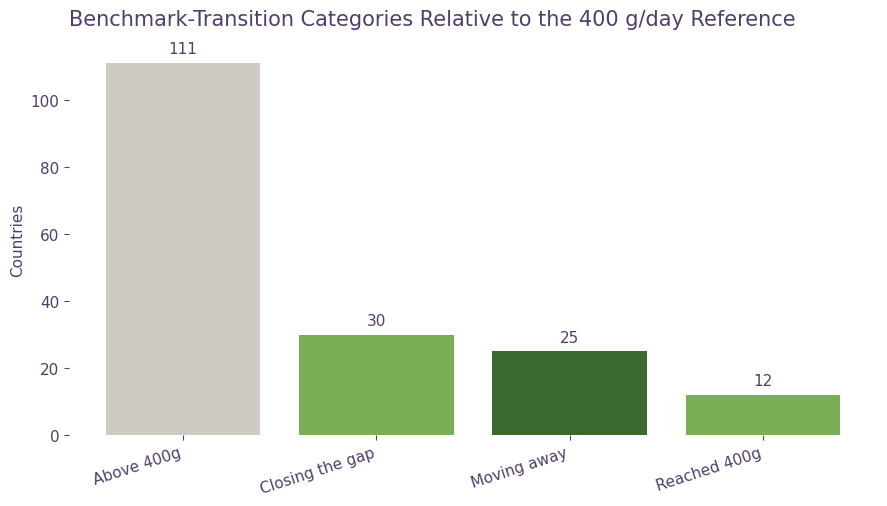

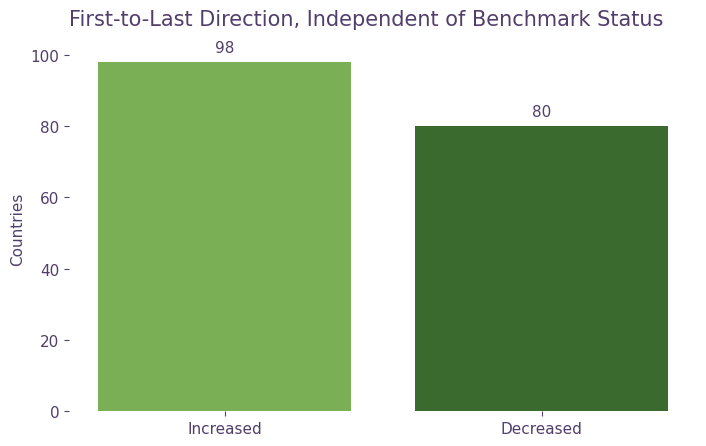

In [0]:
# We plotted the validated benchmark categories, then the independent first-to-last direction counts.

plot_rq2 = (
    rq2_pd
    .dropna(subset=["Progress_Category"])
    .sort_values("count", ascending=False)
    .copy()
)

fig, ax = plt.subplots(figsize=(9, 5.2))

bars = ax.bar(
    plot_rq2["Progress_Category"].astype(str),
    plot_rq2["count"],
    color=[
        FOCUS_DARK if category == "Moving away"
        else FOCUS_COLOR if category in ["Reached 400g", "Closing the gap"]
        else CONTEXT_COLOR
        for category in plot_rq2["Progress_Category"].astype(str)
    ],
    edgecolor="none",
    linewidth=0
)

for bar, value in zip(bars, plot_rq2["count"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{int(value)}",
        ha="center",
        va="bottom",
        color=TEXT_COLOR,
        fontsize=11
    )

ax.set_title(
    "Benchmark-Transition Categories Relative to the 400 g/day Reference",
    loc="left",
    fontsize=15,
    color=TEXT_COLOR,
    pad=14
)
ax.set_ylabel("Countries")
ax.set_xlabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
plt.xticks(rotation=18, ha="right")
plt.tight_layout()
plt.show()

# Separate direction chart: this includes declines even when a country remained above 400 g/day.
plot_direction = (
    rq2_direction_pd
    .dropna(subset=["First_to_Last_Direction"])
    .copy()
)

fig, ax = plt.subplots(figsize=(7.2, 4.6))

bars = ax.bar(
    plot_direction["First_to_Last_Direction"].astype(str),
    plot_direction["count"],
    color=[
        FOCUS_COLOR if direction == "Increased"
        else FOCUS_DARK if direction == "Decreased"
        else CONTEXT_COLOR
        for direction in plot_direction["First_to_Last_Direction"].astype(str)
    ],
    edgecolor="none",
    linewidth=0
)

for bar, value in zip(bars, plot_direction["count"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{int(value)}",
        ha="center",
        va="bottom",
        color=TEXT_COLOR,
        fontsize=11
    )

ax.set_title(
    "First-to-Last Direction, Independent of Benchmark Status",
    loc="left",
    fontsize=15,
    color=TEXT_COLOR,
    pad=14
)
ax.set_ylabel("Countries")
ax.set_xlabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()


#### 3.2.4 Largest Declines Within the `Moving away` Category

We focused on the **10 largest first-to-last declines** among the **25 countries** assigned to the hierarchical `Moving away` category.

The chart highlights the **5 largest declines in the dark olive focus color** and keeps the remaining 5 countries in **grey** as context.

**Important:** these 25 countries are **not all countries with declining availability**. Countries that started and ended above 400 g/day remain classified as `Above 400g` even if their first-to-last availability declined; the independent direction check above captures those cases.


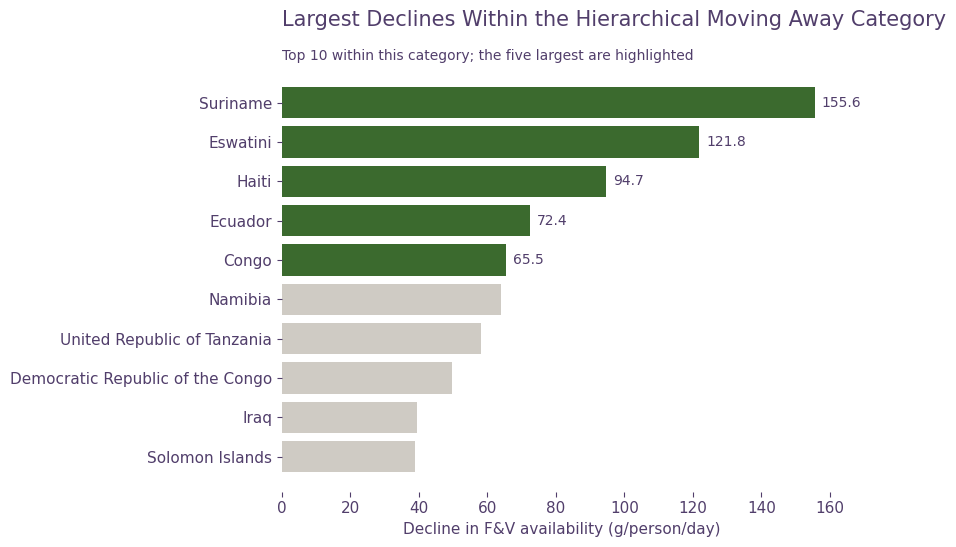

In [0]:
# We focused the chart on the 10 largest declines and greyed the remaining context.

moving_away = (
    country_summary
    .filter(F.col("Progress_Category") == "Moving away")
    .select(
        "Country",
        "Start_FV_g_person_day",
        "End_FV_g_person_day"
    )
    .withColumn(
        "Decline_g_person_day",
        F.round(
            F.col("Start_FV_g_person_day") - F.col("End_FV_g_person_day"),
            1
        )
    )
    .orderBy(F.col("Decline_g_person_day").desc())
)

moving_pd = moving_away.toPandas()

assert len(moving_pd) == 25, "Unexpected number of countries classified as Moving away."

top10_moving = moving_pd.head(10).copy()
top10_moving["Focus_Group"] = ["Focus" if i < 5 else "Context" for i in range(len(top10_moving))]

fig, ax = plt.subplots(figsize=(8.8, 5.6))


bars = ax.barh(
    top10_moving["Country"],
    top10_moving["Decline_g_person_day"],
    color=[FOCUS_DARK if group == "Focus" else CONTEXT_COLOR for group in top10_moving["Focus_Group"]],
    edgecolor="none",
    linewidth=0
)

ax.invert_yaxis()

for idx, (bar, value, group) in enumerate(zip(bars, top10_moving["Decline_g_person_day"], top10_moving["Focus_Group"])):
    if group == "Focus":
        ax.text(
            value + 2,
            bar.get_y() + bar.get_height()/2,
            f"{value:.1f}",
            va="center",
            color=TEXT_COLOR,
            fontsize=10
        )

ax.set_title(
    "Largest Declines Within the Hierarchical Moving Away Category",
    loc="left",
    fontsize=15,
    color=TEXT_COLOR,
    pad=30
)

ax.set_xlabel("Decline in F&V availability (g/person/day)")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

ax.text(
    0.0,
    1.01,
    "Top 10 within this category; the five largest are highlighted",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color=TEXT_COLOR
)

plt.tight_layout()
plt.show()

#### 3.2.5 Key Finding

Across the 178 countries, the **hierarchical benchmark-transition / progress categories** were:

- **111** `Above 400g`
- **12** `Reached 400g`
- **30** `Closing the gap`
- **25** `Moving away`
- **0** `Stable`

The independent direction check gives a different and complementary result:

- **98 countries increased** from their first to last available observation
- **80 countries decreased**
- **0 were stable**

Among the **111 `Above 400g` countries, 55 decreased** while still starting and ending above the reference. This is why `Moving away = 25` should not be read as “only 25 countries declined.”


#### 3.2.6 Interpretation

Most countries started and ended at or above the benchmark, but that should not be interpreted as uninterrupted adequacy or as evidence that all of those countries improved.

The two RQ2 views answer different questions:

- **Benchmark-transition / progress category:** Where did a country start and end relative to 400 g/day, using the validated hierarchy?
- **Independent direction:** Did its apparent F&V availability rise or fall from the first to the last available observation?

The companion direction result shows why the distinction matters: **55 countries declined while remaining in the `Above 400g` category**. The focused `Moving away` chart therefore describes the largest declines **within that hierarchical category**, not all declining countries.

Both views are based on endpoints and do not capture every annual fluctuation between the first and last available observations.


[↑ Back to Table of Contents](#toc)

<a id="rq3"></a>

### 3.3 RQ3 - PATTERNS?
#### What food-system patterns distinguish countries whose period-average F&V availability was below 400 g/day?

RQ3 uses **period-level country measures**:

- RQ1 identifies each country's **period-average benchmark status**
- RQ2 describes **first-to-last movement**
- RQ3 compares **period-average food-system indicators**

For RQ3, every indicator is analysed using the countries with a **valid value for that indicator**. We do not require a country to have complete production, import, and loss data simultaneously before it can contribute to a valid single-indicator analysis.

#### 3.3.1 Missing-Data & Available-Case Approach

RQ3 uses an **available-case approach by indicator**. A country contributes to the production, import, or loss analysis whenever that specific indicator is available. Missing values are not replaced with zero, and a missing value for one indicator does not automatically remove that country from every RQ3 calculation. Each result therefore reports its own valid **n**.

##### Available Cases by Indicator

RQ3 starts from **all 178 countries** and then applies missing-data handling separately for each indicator.

Valid country counts are:

| Indicator | Below 400 | Meets 400 |
|---|---:|---:|
| Period-average production | **56** | **120** |
| Period-average imports | **57** | **121** |
| Period-average loss share | **57** | **120** |

This approach uses the maximum legitimate evidence available for each calculation without imputing missing values.

##### Analytical Base & Sample Sizes

RQ3 starts from **all 178 country-level records** rather than filtering first to one common “complete” subset.

The code counts non-missing period-average values separately for:
- production;
- imports;
- loss share.

This is the operational implementation of the **indicator-complete available-case approach**.

The `Countries_Total` column remains visible so the reader can distinguish:
- the total benchmark-group population, and
- the number of valid observations available for each specific indicator.

The assertion confirms that the RQ3 base still begins with the full 178-country analytical population.

##### RQ3 Gold Metric Derivations

The country-year Gold indicators used in RQ3 are derived from the retained FAOSTAT Food Balance quantities as follows. This documents the transformation explicitly so the per-person measures can be reproduced and defended.

| Gold field | Annual derivation | Unit / interpretation |
|---|---|---|
| `Implied_Population_1000_persons` | `(FV_Food_1000t × 1000) ÷ FV_Supply_kg_cap_yr` | Thousand persons implied by the Food Balance food quantity and kg/capita/year availability field |
| `FV_Production_kg_person_year` | `(FV_Production_1000t × 1000) ÷ Implied_Population_1000_persons` | F&V production, kg/person/year |
| `FV_Imports_kg_person_year` | `(FV_Imports_1000t × 1000) ÷ Implied_Population_1000_persons` | F&V imports, kg/person/year |
| `Loss_Share_pct` | `FV_Losses_1000t ÷ FV_Domestic_Supply_1000t × 100` | Recorded F&V losses as a share of domestic supply |
| Period-average RQ3 fields | Mean of the valid annual indicator values across the country's available study years | Country-period descriptive measure |

The implied-population step avoids introducing a separate population dataset for these per-person Food Balance component measures. Missing or invalid denominators remain missing rather than being converted to zero.


In [0]:
# We started RQ3 with all countries and counted valid observations by indicator.

rq3 = country_summary

rq3_indicator_counts = (
    rq3
    .groupBy("Period_Benchmark_Status")
    .agg(
        F.count("Period_Avg_Production_kg_person_year").alias("Production_n"),
        F.count("Period_Avg_Imports_kg_person_year").alias("Imports_n"),
        F.count("Period_Avg_Loss_Share_pct").alias("Loss_Share_n"),
        F.count("*").alias("Countries_Total")
    )
    .orderBy("Period_Benchmark_Status")
)

display(rq3_indicator_counts)

assert rq3.count() == 178, "RQ3 country base should contain all 178 countries."

Period_Benchmark_Status,Production_n,Imports_n,Loss_Share_n,Countries_Total
Below 400g,56,57,57,57
Meets 400g,120,121,120,121


#### 3.3.2 Food-System Profile Comparison

We compare medians because country-level production and trade measures are highly heterogeneous and can contain very large values.

The comparison uses:

- **Period-average F&V production per person**
- **Period-average F&V imports per person**
- **Period-average recorded loss share**

##### Exact Median Comparisons

We compared countries **Below 400g** with countries **Meeting 400g** using exact country-level medians for production, imports, and recorded loss share.

Medians are used because country-level production and trade measures are highly skewed and can contain very large values. Each indicator reports its own valid `n` because the available-case approach does not force all indicators to share the same sample size.

With only 178 country-level records, the exact median is calculated directly in Pandas rather than using an approximate percentile function.

In [0]:
# We calculated exact country-level medians and valid sample sizes for each indicator.

rq3_country_pd = (
    rq3.select(
        "Period_Benchmark_Status",
        "Period_Avg_Production_kg_person_year",
        "Period_Avg_Imports_kg_person_year",
        "Period_Avg_Loss_Share_pct"
    )
    .toPandas()
)

rq3_summary_pd = (
    rq3_country_pd
    .groupby("Period_Benchmark_Status", as_index=False)
    .agg(
        Median_Production_kg_person_year=("Period_Avg_Production_kg_person_year", "median"),
        Production_n=("Period_Avg_Production_kg_person_year", "count"),
        Median_Imports_kg_person_year=("Period_Avg_Imports_kg_person_year", "median"),
        Imports_n=("Period_Avg_Imports_kg_person_year", "count"),
        Median_Loss_Share_pct=("Period_Avg_Loss_Share_pct", "median"),
        Loss_Share_n=("Period_Avg_Loss_Share_pct", "count")
    )
)

rq3_summary = spark.createDataFrame(rq3_summary_pd)

display(rq3_summary)

Period_Benchmark_Status,Median_Production_kg_person_year,Production_n,Median_Imports_kg_person_year,Imports_n,Median_Loss_Share_pct,Loss_Share_n
Below 400g,97.23905851518441,56,11.773372558549598,57,8.635652751927733,57
Meets 400g,215.32422322350237,120,99.68812050274836,121,7.093946671673706,120


##### Group Comparison Results

| Indicator | Below 400 | Meets 400 |
|---|---:|---:|
| Median period-average F&V production | **97.2 kg/person/year (n=56)** | **215.3 kg/person/year (n=120)** |
| Median period-average F&V imports | **11.8 kg/person/year (n=57)** | **99.7 kg/person/year (n=121)** |
| Median period-average loss share | **8.6% (n=57)** | **7.1% (n=120)** |

The largest descriptive differences appear in **production and imports**. Recorded loss share differs much less between the two groups.

Because valid sample size differs slightly by indicator, each result reports its own **n** rather than implying one fixed RQ3 sample.

##### Individual Indicator Charts

We visualized **production, imports, and recorded loss share as three separate figures** so each can be reviewed and copied independently.

Within each figure, the two benchmark groups are ordered from the larger median to the smaller median, while the olive focus color highlights the **Below 400** group.

In [0]:
# We prepared the RQ3 summary once for the three indicator charts.

rq3_summary_pd = rq3_summary.toPandas().copy()
rq3_summary_pd["Display_Status"] = rq3_summary_pd["Period_Benchmark_Status"].replace({
    "Below 400g": "Below 400",
    "Meets 400g": "Meets 400"
})

status_order = ["Below 400", "Meets 400"]

###### Production

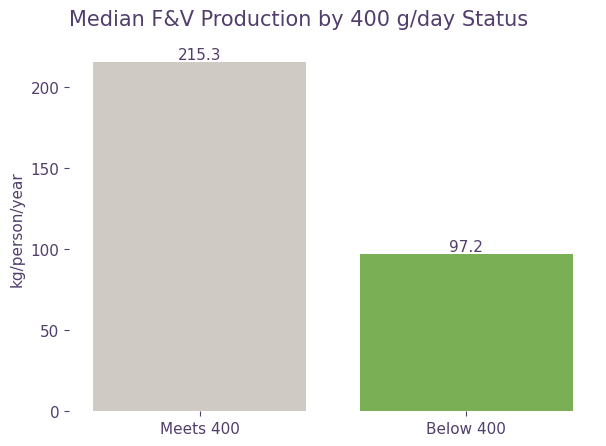

In [0]:
# We compared median F&V production between the two benchmark groups.

chart_df = (
    rq3_summary_pd
    .set_index("Display_Status")
    .reindex(status_order)
    .reset_index()
    .sort_values("Median_Production_kg_person_year", ascending=False)
)

fig, ax = plt.subplots(figsize=(6.2, 4.6))

bars = ax.bar(
    chart_df["Display_Status"],
    chart_df["Median_Production_kg_person_year"],
    color=[FOCUS_COLOR if status == "Below 400" else CONTEXT_COLOR for status in chart_df["Display_Status"]],
    edgecolor="none",
    linewidth=0
)

for bar, value in zip(bars, chart_df["Median_Production_kg_person_year"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
        color=TEXT_COLOR,
        fontsize=11
    )

ax.set_title(
    "Median F&V Production by 400 g/day Status",
    loc="left",
    fontsize=15,
    color=TEXT_COLOR,
    pad=14
)
ax.set_ylabel("kg/person/year")
ax.set_xlabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

###### Imports

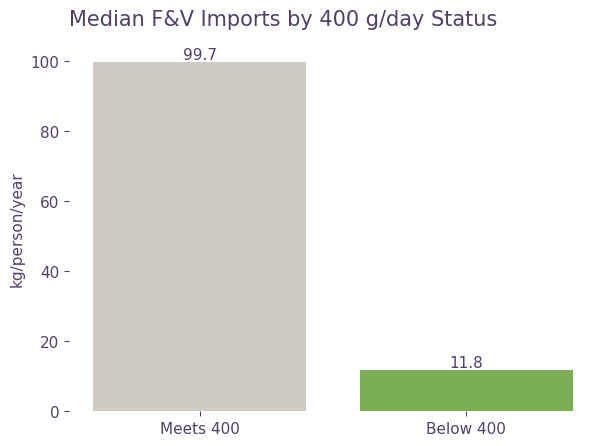

In [0]:
# We compared median F&V imports between the two benchmark groups.

chart_df = (
    rq3_summary_pd
    .set_index("Display_Status")
    .reindex(status_order)
    .reset_index()
    .sort_values("Median_Imports_kg_person_year", ascending=False)
)

fig, ax = plt.subplots(figsize=(6.2, 4.6))

bars = ax.bar(
    chart_df["Display_Status"],
    chart_df["Median_Imports_kg_person_year"],
    color=[FOCUS_COLOR if status == "Below 400" else CONTEXT_COLOR for status in chart_df["Display_Status"]],
    edgecolor="none",
    linewidth=0
)

for bar, value in zip(bars, chart_df["Median_Imports_kg_person_year"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
        color=TEXT_COLOR,
        fontsize=11
    )

ax.set_title(
    "Median F&V Imports by 400 g/day Status",
    loc="left",
    fontsize=15,
    color=TEXT_COLOR,
    pad=14
)
ax.set_ylabel("kg/person/year")
ax.set_xlabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

###### Recorded Loss Share

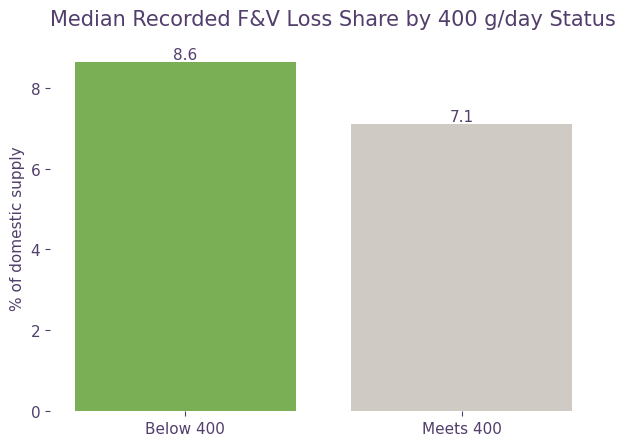

In [0]:
# We compared median recorded loss share between the two benchmark groups.

chart_df = (
    rq3_summary_pd
    .set_index("Display_Status")
    .reindex(status_order)
    .reset_index()
    .sort_values("Median_Loss_Share_pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(6.2, 4.6))

bars = ax.bar(
    chart_df["Display_Status"],
    chart_df["Median_Loss_Share_pct"],
    color=[FOCUS_COLOR if status == "Below 400" else CONTEXT_COLOR for status in chart_df["Display_Status"]],
    edgecolor="none",
    linewidth=0
)

for bar, value in zip(bars, chart_df["Median_Loss_Share_pct"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
        color=TEXT_COLOR,
        fontsize=11
    )

ax.set_title(
    "Median Recorded F&V Loss Share by 400 g/day Status",
    loc="left",
    fontsize=15,
    color=TEXT_COLOR,
    pad=14
)
ax.set_ylabel("% of domestic supply")
ax.set_xlabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

#### 3.3.3 Relationships Within Below-400 Countries

The correlation stage focuses only on countries whose **period-average availability is below 400 g/day**.

Three relationships are examined:

1. Production vs period-average F&V availability
2. Imports vs period-average F&V availability
3. Recorded loss share vs period-average shortfall

**Important structural caveat:** production and imports are components of the broader food-balance accounting system from which apparent availability is derived. A positive association with availability is therefore partly expected from the accounting structure. These correlations are used as **descriptive food-balance diagnostics**, not as estimates of independent effects or causal drivers.

Pearson correlations summarize **linear association only**.


##### Correlation Sample

The correlation stage asks a narrower question than the group comparison:

> **Within countries whose period-average availability is below 400 g/day, how are food-system indicators associated with the size or level of the availability gap?**

We therefore:
1. filtered the full RQ3 country table to `Below 400g`;
2. selected only the variables needed for the three correlation tests;
3. converted the small country-level table to Pandas;
4. reported how many below-400 countries have a valid value for each indicator.

Importantly, the table is **not pre-filtered to complete cases across all three indicators**. Pairwise missing-value handling occurs separately for each correlation in the next cell.

In [0]:
# We restricted correlation analysis to countries below 400 g/day on period average.

rq3_below = (
    rq3
    .filter(F.col("Period_Benchmark_Status") == "Below 400g")
    .select(
        "Country",
        "Period_Avg_FV_g_person_day",
        "Period_Shortfall_g_day",
        "Period_Avg_Production_kg_person_year",
        "Period_Avg_Imports_kg_person_year",
        "Period_Avg_Loss_Share_pct"
    )
)

rq3_below_pd = rq3_below.toPandas()

print("Below-400 countries in RQ3 base:", len(rq3_below_pd))
print("Production available:", rq3_below_pd["Period_Avg_Production_kg_person_year"].notna().sum())
print("Imports available:", rq3_below_pd["Period_Avg_Imports_kg_person_year"].notna().sum())
print("Loss share available:", rq3_below_pd["Period_Avg_Loss_Share_pct"].notna().sum())

Below-400 countries in RQ3 base: 57
Production available: 56
Imports available: 57
Loss share available: 57


##### Pearson Correlations

We calculated the three final RQ3 correlations using **pairwise complete observations**.

The helper function:
- keeps only the two variables needed for one relationship;
- removes rows missing either of those two values;
- calculates the Pearson correlation coefficient;
- returns both `r` and the valid sample size `n`.

This means a country with valid production and availability can contribute to the production correlation even if its loss-share value is missing.

The three tested relationships are:
1. production vs F&V availability;
2. imports vs F&V availability;
3. loss share vs 400G shortfall.

Pearson `r` measures **linear association**, not causation.

In [0]:
# We calculated Pearson correlations using pairwise-complete observations.

def pearson_result(data, x_col, y_col):
    clean = data[[x_col, y_col]].dropna()
    r = clean[x_col].corr(clean[y_col])
    return float(r), int(len(clean))

correlation_specs = [
    (
        "Production vs F&V availability",
        "Period_Avg_Production_kg_person_year",
        "Period_Avg_FV_g_person_day"
    ),
    (
        "Imports vs F&V availability",
        "Period_Avg_Imports_kg_person_year",
        "Period_Avg_FV_g_person_day"
    ),
    (
        "Loss share vs 400G shortfall",
        "Period_Avg_Loss_Share_pct",
        "Period_Shortfall_g_day"
    )
]

corr_rows = []
for relationship, x_col, y_col in correlation_specs:
    r, n = pearson_result(rq3_below_pd, x_col, y_col)
    corr_rows.append({
        "Relationship": relationship,
        "Pearson_r": round(r, 3),
        "n": n
    })

corr_results_pd = pd.DataFrame(corr_rows)
display(spark.createDataFrame(corr_results_pd))

Relationship,Pearson_r,n
Production vs F&V availability,0.456,56
Imports vs F&V availability,0.247,57
Loss share vs 400G shortfall,-0.221,57


##### Correlation Results

Using **pairwise complete observations** among period-average below-400 countries:

- **Production vs availability:** **r = 0.46, n = 56**
- **Imports vs availability:** **r = 0.25, n = 57**
- **Loss share vs shortfall:** **r = -0.22, n = 57**

Production again provides the clearest signal, while imports show a weaker positive relationship. Recorded loss share does not show a strong positive relationship with shortfall size.

The different **n** values are intentional: each relationship uses all countries with valid data for the variables involved.

##### Reusable Correlation Plot Function

We used one function to standardize the appearance and calculation logic of the three RQ3 scatterplots.

For each relationship it:
- applies the same pairwise-complete filtering used for the numerical correlation;
- calculates Pearson `r`;
- plots individual countries as neutral context points;
- fits a simple linear trend line when sufficient variation exists;
- optionally adds the black dotted **400g** benchmark;
- displays both `r` and `n` directly on the figure.

Using one shared function prevents small styling or filtering differences from being introduced across the production, import, and loss charts.

The fitted line is descriptive only and should not be interpreted as a causal model.

In [0]:
# We used one plotting function to keep filtering and styling consistent across correlations.

def plot_correlation(
    data,
    x_col,
    y_col,
    x_label,
    y_label,
    title,
    benchmark_y=None
):
    clean = data[[x_col, y_col]].dropna().copy()
    r = clean[x_col].corr(clean[y_col])

    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    ax.scatter(
        clean[x_col],
        clean[y_col],
        s=36,
        alpha=0.62,
        color=CONTEXT_DARK,
        edgecolors="none"
    )

    if len(clean) >= 2 and clean[x_col].nunique() > 1:
        slope, intercept = np.polyfit(clean[x_col], clean[y_col], 1)
        x_vals = np.linspace(clean[x_col].min(), clean[x_col].max(), 200)
        ax.plot(
            x_vals,
            slope * x_vals + intercept,
            color=FOCUS_COLOR,
            linewidth=2.5
        )

    if benchmark_y is not None:
        ax.axhline(
            benchmark_y,
            color=BENCH_COLOR,
            linestyle=":",
            linewidth=1.5,
            zorder=5
        )
        ax.text(
            0.99,
            benchmark_y,
            "400g",
            transform=ax.get_yaxis_transform(),
            ha="right",
            va="bottom",
            color=BENCH_COLOR,
            fontsize=10
        )

    ax.set_title(
        title,
        loc="left",
        fontsize=15,
        color=TEXT_COLOR,
        pad=14
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    ax.text(
        0.02,
        0.98,
        f"r = {r:.2f}   n = {len(clean)}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        color=TEXT_COLOR,
        fontsize=11
    )

    plt.tight_layout()
    plt.show()

    return r, len(clean)

##### Production vs Availability

This cell applies the shared correlation function to **period-average F&V production per person** and **period-average F&V availability** among below-400 countries.

The 400 g/day horizontal reference is retained so the viewer can see how the observations sit relative to the benchmark even though all countries in this subset have period-average values below it.

The returned `production_r` and `production_n` preserve the exact statistic and pairwise-complete sample size used in the figure.

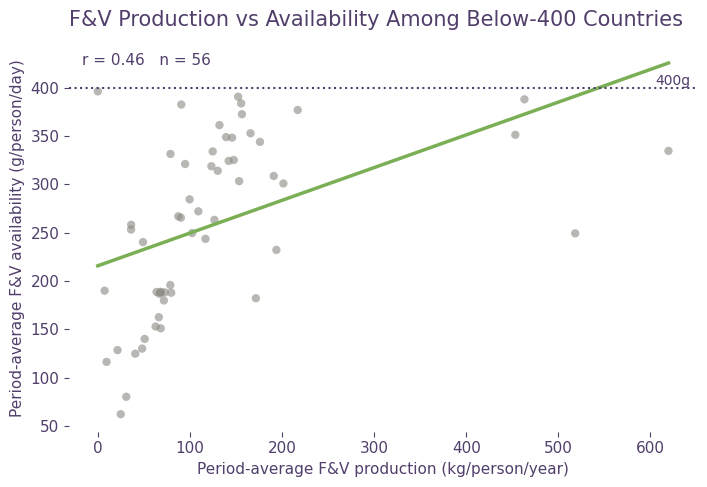

In [0]:
# We tested the relationship between production and period-average F&V availability.

production_r, production_n = plot_correlation(
    rq3_below_pd,
    x_col="Period_Avg_Production_kg_person_year",
    y_col="Period_Avg_FV_g_person_day",
    x_label="Period-average F&V production (kg/person/year)",
    y_label="Period-average F&V availability (g/person/day)",
    title="F&V Production vs Availability Among Below-400 Countries",
    benchmark_y=400
)

**Interpretation:** Production shows a **moderate positive food-balance component association** with period-average F&V availability among countries below the reference. Higher production per person tends to coincide with higher apparent availability, but part of this relationship is structurally expected because production contributes to the food-balance accounting system. The result is descriptive, is not deterministic, and does not establish an independent or causal production effect.


##### Imports vs Availability

This cell applies the same pairwise-complete correlation and visualization logic to **period-average F&V imports per person**.

Keeping the same function, benchmark treatment, and visual grammar as the production plot makes the two relationships directly comparable in presentation while preserving their separate underlying sample sizes.

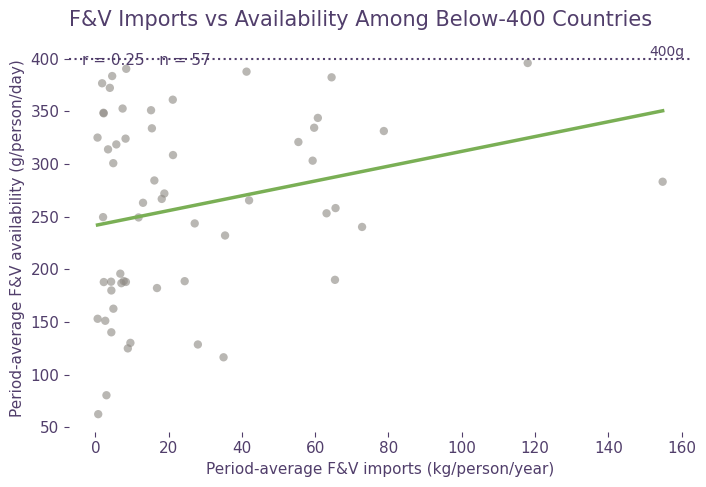

In [0]:
# We tested the relationship between imports and period-average F&V availability.

imports_r, imports_n = plot_correlation(
    rq3_below_pd,
    x_col="Period_Avg_Imports_kg_person_year",
    y_col="Period_Avg_FV_g_person_day",
    x_label="Period-average F&V imports (kg/person/year)",
    y_label="Period-average F&V availability (g/person/day)",
    title="F&V Imports vs Availability Among Below-400 Countries",
    benchmark_y=400
)

**Interpretation:** Imports show a **weaker positive association** with availability. Imported supply may complement domestic production in some settings, but import dependence, purchasing power, distribution, affordability, and other factors can shape how trade translates into apparent availability.

##### Recorded Loss Share vs Shortfall

This cell examines whether countries with a higher **recorded F&V loss share** also tend to have a larger shortfall from the 400 g/day reference.

The y-variable here is **shortfall**, not availability:
- a larger value means the country is farther below 400 g/day;
- a value closer to zero means it is nearer the benchmark.

The same available-case rule applies: only countries with both a valid loss-share value and a valid shortfall enter this correlation.

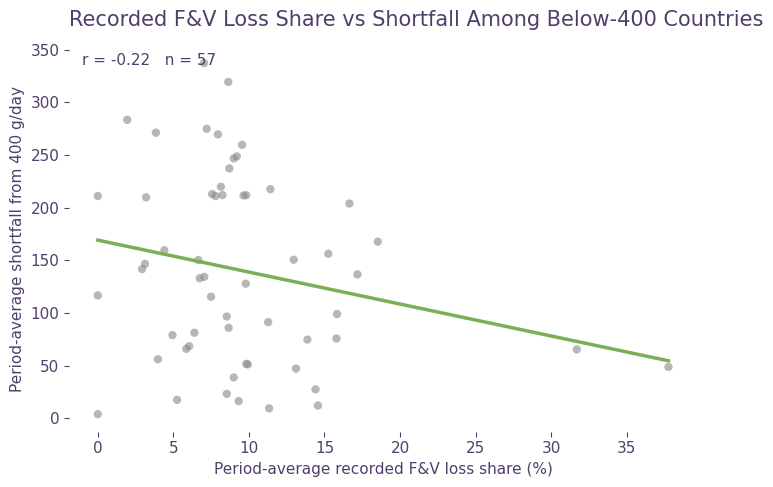

In [0]:
# We tested the relationship between recorded loss share and the shortfall from 400 g/day.

loss_r, loss_n = plot_correlation(
    rq3_below_pd,
    x_col="Period_Avg_Loss_Share_pct",
    y_col="Period_Shortfall_g_day",
    x_label="Period-average recorded F&V loss share (%)",
    y_label="Period-average shortfall from 400 g/day",
    title="Recorded F&V Loss Share vs Shortfall Among Below-400 Countries",
)

**Interpretation:** Recorded loss share shows only a **weak inverse linear relationship** with shortfall size in this sample. The available loss measure therefore does not emerge as a strong standalone explanation of why some countries remain farther below 400 g/day.

[↑ Back to Table of Contents](#toc)

<a id="robustness"></a>

## 4. Robustness & Interpretation

The methodology prioritizes **internal consistency, transparent coverage, and restrained interpretation**, with a clearly defined time basis for each research question.

<a id="safeguards"></a>

### 4.1 Analytical Safeguards

**1. Consistent analytical source:**  
All results are generated from the same consolidated country-year dataset.

**2. Country-year and country-period integrity checks:**  
Before creating the one-row-per-country view, the notebook checks for duplicate country-year rows, one-to-one Country↔M49 mapping, and conflicting repeated country-period fields. This prevents `dropDuplicates(["Country"])` from silently hiding inconsistent values.

**3. Geography is kept at the country level:**
Official regional aggregates are not mixed with country observations in the primary analysis.

**4. Partial country coverage is disclosed:**
Countries do not all have identical year coverage. RQ1 uses available observations; RQ2 uses first and last available observations. Coverage fields remain in the Gold data so this can be inspected.

**5. Missing source components are not treated as zero:**
Production, imports, and loss share are analysed with an **available-case approach**. A missing value removes a country only from the calculation that requires that indicator; it does not automatically remove the country from every RQ3 analysis.

**6. Sample size is reported separately by indicator:**
Group medians and correlations report their own **n** so differences in indicator availability remain transparent.

**7. Medians are used for group comparisons:**
Country-level production and trade values are skewed and heterogeneous, so medians reduce sensitivity to extreme observations.

**8. Correlation is not interpreted as causation:**
Production, imports, and losses are examined as diagnostic patterns only.

**9. Rank-based sensitivity check:**
Pearson results are compared with Spearman correlations to test whether the broad interpretation changes when rank order is used instead of a strictly linear measure.

**10. Coverage sensitivity check:**  
The headline benchmark and progress summaries are re-run on the 168 countries with complete 2014–2023 coverage to assess whether partial coverage materially changes the story.


<a id="coverage-sensitivity"></a>

### 4.2 Coverage Sensitivity Check

The primary RQ1 and RQ2 results retain all countries with valid observations, including 10 countries with partial year coverage. As a sensitivity check, we repeat the headline benchmark and trajectory summaries using only the **168 countries with all 10 years (2014–2023)**.

This does not replace the primary analysis. It tests whether the broad story changes materially when incomplete time coverage is excluded.


In [0]:
# Sensitivity analysis restricted to countries with all 10 study years.

complete_country_summary = country_summary.filter(F.col("Years_Observed") == 10)

coverage_sensitivity = (
    complete_country_summary
    .agg(
        F.count("*").alias("Countries"),
        F.sum(
            F.when(F.col("Period_Benchmark_Status") == "Below 400g", 1).otherwise(0)
        ).alias("Below_400"),
        F.sum(
            F.when(F.col("Progress_Category") == "Moving away", 1).otherwise(0)
        ).alias("Moving_Away")
    )
    .withColumn(
        "Below_400_pct",
        F.round(F.col("Below_400") / F.col("Countries") * 100, 1)
    )
)

complete_progress = (
    complete_country_summary
    .groupBy("Progress_Category")
    .count()
    .orderBy(F.col("count").desc())
)

assert complete_country_summary.count() == 168, "Complete-coverage sensitivity sample should contain 168 countries."

print("Complete-coverage headline sensitivity:")
display(coverage_sensitivity)

print("Complete-coverage RQ2 category distribution:")
display(complete_progress)

Complete-coverage headline sensitivity:


Countries,Below_400,Moving_Away,Below_400_pct
168,53,25,31.5


Complete-coverage RQ2 category distribution:


Progress_Category,count
Above 400g,105
Closing the gap,26
Moving away,25
Reached 400g,12


<a id="sensitivity"></a>

### 4.3 Pearson vs Spearman Sensitivity Check

We compared the primary **Pearson correlations** with **Spearman rank correlations** using the same pairwise-complete Below-400 samples.

Spearman correlation is less sensitive to extreme values and does not require a strictly linear relationship, so it provides a useful sensitivity check for the direction and relative strength of the observed associations.

In [0]:
# We compared Pearson and Spearman correlations on the same pairwise-complete samples.

robustness_specs = [
    (
        "Production",
        "Period_Avg_Production_kg_person_year",
        "Period_Avg_FV_g_person_day"
    ),
    (
        "Imports",
        "Period_Avg_Imports_kg_person_year",
        "Period_Avg_FV_g_person_day"
    ),
    (
        "Recorded loss share",
        "Period_Avg_Loss_Share_pct",
        "Period_Shortfall_g_day"
    )
]

robustness_rows = []

for indicator, x_col, y_col in robustness_specs:
    pair = rq3_below_pd[[x_col, y_col]].dropna()

    robustness_rows.append({
        "Indicator": indicator,
        "n": len(pair),
        "Pearson_r": pair[x_col].corr(pair[y_col], method="pearson"),
        "Spearman_rho": pair[x_col].corr(pair[y_col], method="spearman")
    })

robustness_results = pd.DataFrame(robustness_rows).round({
    "Pearson_r": 2,
    "Spearman_rho": 2
})

display(robustness_results)

Indicator,n,Pearson_r,Spearman_rho
Production,56,0.46,0.65
Imports,57,0.25,0.18
Recorded loss share,57,-0.22,-0.19


#### Robustness Interpretation

The rank-based check supports the same broad descriptive pattern:

- **Production:** positive under both measures (**Pearson r = 0.46; Spearman ρ = 0.65; n = 56**)
- **Imports:** weak positive association (**r = 0.25; ρ = 0.18; n = 57**)
- **Recorded loss share:** weak negative association with shortfall size (**r = -0.22; ρ = -0.19; n = 57**)

Production remains the clearest **food-balance component association** in this exploratory comparison, while imports and recorded loss share remain comparatively weak. The stronger Spearman than Pearson coefficient for production suggests a monotonic relationship that is not perfectly linear.

Because production and imports contribute to the broader Food Balance accounting system, these coefficients should not be interpreted as evidence that either variable independently causes the observed availability gap.


<a id="guardrails"></a>

### 4.4 Interpretation Guardrails

The project uses **400 g/day as a food-system reference benchmark**.

FAOSTAT Food Balance data describe **apparent national availability**, not:
- individual dietary intake,
- within-country inequality,
- affordability,
- household access,
- food preference,
- dietary quality beyond F&V quantity.

A country whose national apparent availability meets 400 g/day can still contain populations with inadequate access or consumption. Likewise, a country below 400 g/day may face multiple interacting supply, distribution, economic, and demand-side constraints.

[↑ Back to Table of Contents](#toc)

<a id="implications"></a>

## 5. Implications & Conclusion

<a id="evidence-implications"></a>

### 5.1 Evidence-Aligned Implications

The analysis supports a **diagnostic sequence**, not a universal policy prescription.

**1. Use the period-average gap to identify persistent supply concerns.**  
Countries with the largest period-average shortfalls warrant closer examination because their national apparent F&V availability was furthest from the 400 g/day reference on average across the study period.

**2. Use benchmark transition and independent direction together.**  
A below-reference country that is closing the gap presents a different analytical problem from one moving away. Likewise, a country can decline while still remaining above the benchmark at both endpoints, so benchmark status should not substitute for a direct direction check.

**3. Examine production as one food-balance component, not as a standalone causal explanation.**  
Production showed the clearest descriptive association with availability among the selected Food Balance components, but this is partly structurally expected because production contributes to the accounting system that underlies apparent availability.

**4. Examine import capacity and market access alongside production.**  
Imports were substantially lower among below-400 countries and showed a weaker positive association with availability. This pattern may identify countries where trade is an important part of the supply context, but it does not establish that low imports caused the gap.

**5. Treat recorded losses as one part of a broader food-system diagnosis.**  
The loss measure did not show a strong relationship with shortfall size, so loss reduction alone should not be inferred as the primary explanation from this dataset.

The practical next step is therefore to combine **gap size + benchmark transition + direction of travel + food-system profile** for countries facing the largest shortfalls, then investigate additional context only where it materially helps explain those observed patterns.


<a id="priority-diagnostic"></a>

#### 5.1.1 Priority Country Diagnostic Table

For practical follow-up, this table combines the headline shortfall with trajectory and the three exploratory food-system indicators for the **15 countries with the largest period-average shortfalls**.

The ranking is determined **only by shortfall size**. Production, imports, recorded loss share, and progress category are shown as diagnostic context. They should not be interpreted as causal explanations or as a complete policy-priority score.


In [0]:
# Integrate gap size, trajectory, and RQ3 indicators for the 15 deepest shortfalls.

priority_diagnostic = (
    country_summary
    .filter(F.col("Period_Benchmark_Status") == "Below 400g")
    .select(
        "Country",
        "Period_Avg_FV_g_person_day",
        "Period_Shortfall_g_day",
        "Supply_Adequacy_pct",
        "Progress_Category",
        "Period_Avg_Production_kg_person_year",
        "Period_Avg_Imports_kg_person_year",
        "Period_Avg_Loss_Share_pct",
        "Years_Observed",
        "Coverage_Status"
    )
    .orderBy(
        F.col("Period_Shortfall_g_day").desc(),
        F.col("Country").asc()
    )
    .limit(15)
)

display(priority_diagnostic)

Country,Period_Avg_FV_g_person_day,Period_Shortfall_g_day,Supply_Adequacy_pct,Progress_Category,Period_Avg_Production_kg_person_year,Period_Avg_Imports_kg_person_year,Period_Avg_Loss_Share_pct,Years_Observed,Coverage_Status
Ethiopia,62.51506849315068,337.4849315068493,15.6,Closing the gap,24.854250248117836,0.7608022555414076,7.032853588570799,10,Complete 2014-2023
Zambia,80.4876712328767,319.5123287671233,20.1,Moving away,30.905191341177133,3.005324877583048,8.635652751927733,10,Complete 2014-2023
Gambia,116.53424657534246,283.4657534246575,29.1,Moving away,9.514659912314784,34.977476834333565,1.9458677906161908,10,Complete 2014-2023
Timor-Leste,124.98082191780821,275.0191780821918,31.2,Closing the gap,40.6955142688468,8.84371558400708,7.207137612570826,10,Complete 2014-2023
Lesotho,128.6931506849315,271.30684931506846,32.2,Moving away,21.426607885293507,27.964004550070612,3.8423241402200627,10,Complete 2014-2023
Yemen,130.23835616438356,269.76164383561644,32.6,Moving away,48.11770166702149,9.546720871060494,7.946899659134967,10,Complete 2014-2023
Solomon Islands,140.26027397260273,259.7397260273973,35.1,Moving away,50.89303555451823,4.33843770835921,9.549182686588892,10,Complete 2014-2023
Cambodia,151.2027397260274,248.7972602739726,37.8,Moving away,68.31667067138456,2.6822740257450337,9.199038368104569,10,Complete 2014-2023
Madagascar,153.1041095890411,246.8958904109589,38.3,Moving away,62.743077332999356,0.603843945022031,8.994576637486247,10,Complete 2014-2023
Pakistan,162.67123287671234,237.32876712328766,40.7,Moving away,66.257771436332,4.9022941667492015,8.702291827479598,10,Complete 2014-2023


<a id="final-synthesis"></a>

### 5.2 Final Synthesis

**RQ1 - WHERE?**

**57 of 178 countries (32.0%)** had period-average apparent F&V availability below 400 g/person/day during their available observations within 2014–2023. The analysis also ranks the countries with the **largest period-average shortfalls** and reports **Supply Adequacy %**, directly showing which countries were furthest below the reference.

**RQ2 - PROGRESS?**

The validated hierarchical benchmark-transition / progress categories were:
- **111 Above 400g**
- **12 Reached 400g**
- **30 Closing the gap**
- **25 Moving away**

A separate direction check shows that **98 countries increased and 80 decreased** from their first to last available observation. **55 of the 111 `Above 400g` countries declined while still starting and ending above the reference**, demonstrating why threshold category and direction must be interpreted separately.

**RQ3 - PATTERNS?**

Using all valid observations available for each indicator, below-400 countries had substantially lower median production and imports than countries meeting the reference.

Among below-400 countries with valid data for each specific relationship:
- production had the clearest positive **food-balance component association** with availability (**r = 0.46, n = 56**),
- imports showed a weaker positive relationship (**r = 0.25, n = 57**),
- recorded loss share showed little relationship with shortfall size (**r = -0.22, n = 57**).

These are descriptive associations. Production and imports are part of the broader food-balance accounting structure and are not interpreted as independent causal drivers.

#### Overall Takeaway

The 400G challenge is **not only about whether enough fruits and vegetables exist globally**. National apparent availability remains uneven, countries differ in gap size, benchmark transition, and direction of travel, and below-reference countries show different food-system profiles.

The analysis therefore supports a **country-specific diagnostic approach**: identify the size of the gap, distinguish benchmark transition from direction, examine the accompanying food-system profile, and then investigate the context most relevant to that country.


<a id="limitations"></a>

### 5.3 Limitations

- FAOSTAT Food Balance Sheets measure **apparent national food availability**, not individual consumption.
- The analysis covers **2014–2023**.
- RQ1 averages each country's **available observations**, so countries with partial coverage contribute fewer years.
- RQ2 uses **first and last available observations**, which are not identical calendar endpoints for every country.
- `Progress_Category` is hierarchical and combines benchmark status with movement; an `Above 400g` country can still have a first-to-last decline. RQ2 therefore reports an independent direction check as a companion result.
- Both RQ2 views summarize endpoints and do not capture every fluctuation between them.
- Country-period averages can smooth meaningful year-to-year variation.
- The period-average and annual maps cap the color scale at **800 g/person/day** for readability; values above that level are visually saturated and should be read from hover values rather than color alone.
- Maps rely on Plotly geographic name matching. Known FAOSTAT naming variants are normalized for visualization, but final exported maps should still be visually checked for any missing or unmatched geography.
- RQ3 uses period-average production, imports, and recorded loss share; these indicators do not capture every food-system constraint.
- Production and imports contribute to the broader Food Balance accounting system, so observed correlations with apparent availability are not estimates of independent effects.
- RQ3 uses **available cases by indicator**, so sample size can differ slightly across production, import, and loss analyses.
- Available-case analysis assumes that excluding missing observations does not introduce important systematic bias; results should therefore be interpreted descriptively.
- Pearson correlation measures linear association only and is sensitive to data structure and outliers; Spearman rank correlations are included as a sensitivity check.
- The priority diagnostic table ranks countries by **shortfall only**; it is not a comprehensive policy-priority index.
- No causal claims are made.
- The 400 g/day value is used as a **reference benchmark**, not as proof of adequate individual dietary intake or access.


<a id="sources"></a>

### 5.4 Sources & References

1. **World Health Organization (WHO).** *Healthy diet.*  
   https://www.who.int/news-room/fact-sheets/detail/healthy-diet  
   Used for the **400 g/day fruit-and-vegetable reference**.

2. **Food and Agriculture Organization of the United Nations (FAO).** *FAOSTAT Food Balances (Global, National — Annual).*  
   https://data.fao.org/catalog/iso/2f264bb6-1238-459a-bf8b-0e2d0a16804a  
   Primary source for the **Food Balance** data used in the analysis.

3. **FAOSTAT Food Balances metadata.**  
   https://www.fao.org/faostat/en/#data/FBS/metadata  
   Used for dataset definitions, units, source flags, and interpretation of Food Balance elements.

[↑ Back to Table of Contents](#toc)